In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [7]:
df = pd.read_csv("/content/Heart Attack.csv")
df

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative
...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,negative
1315,66,1,84,125,55,149.0,1.33,0.172,positive
1316,45,1,85,168,104,96.0,1.24,4.250,positive
1317,54,1,58,117,68,443.0,5.80,0.359,positive


In [8]:
X = df.drop("class",axis =1)
Y =df["class"]

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=42)

In [10]:
model = RandomForestClassifier()

In [11]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(1055, 8)
(264, 8)
(1055,)
(264,)


In [12]:
model.fit(X_train,Y_train)

RandomForestClassifier()

In [13]:
y_pred = model.predict(X_test)
print(y_pred)

['positive' 'negative' 'negative' 'negative' 'positive' 'positive'
 'positive' 'positive' 'positive' 'negative' 'negative' 'negative'
 'positive' 'positive' 'positive' 'negative' 'positive' 'positive'
 'negative' 'negative' 'negative' 'negative' 'positive' 'positive'
 'positive' 'positive' 'negative' 'negative' 'positive' 'negative'
 'negative' 'negative' 'positive' 'negative' 'positive' 'negative'
 'positive' 'positive' 'negative' 'positive' 'positive' 'negative'
 'positive' 'positive' 'negative' 'positive' 'positive' 'positive'
 'negative' 'positive' 'negative' 'positive' 'positive' 'negative'
 'negative' 'positive' 'positive' 'negative' 'negative' 'positive'
 'positive' 'positive' 'negative' 'positive' 'negative' 'positive'
 'positive' 'positive' 'positive' 'negative' 'positive' 'negative'
 'positive' 'positive' 'positive' 'positive' 'negative' 'positive'
 'positive' 'positive' 'positive' 'positive' 'positive' 'negative'
 'positive' 'negative' 'positive' 'negative' 'positive' 'negat

In [14]:
accuracy = accuracy_score(Y_test,y_pred)
print("Accuracy :",accuracy*100)
cm = confusion_matrix(Y_test,y_pred)
print("confusion_matrix : ",cm)
cl = classification_report(Y_test,y_pred)
print("classification_report:",cl)

Accuracy : 98.10606060606061
confusion_matrix :  [[ 99   2]
 [  3 160]]
classification_report:               precision    recall  f1-score   support

    negative       0.97      0.98      0.98       101
    positive       0.99      0.98      0.98       163

    accuracy                           0.98       264
   macro avg       0.98      0.98      0.98       264
weighted avg       0.98      0.98      0.98       264



In [15]:
print(model.feature_importances_)

[0.05225194 0.00945677 0.01666926 0.02446945 0.02119502 0.02876674
 0.25887881 0.58831202]


In [16]:
importance = model.feature_importances_

In [17]:
feature_importance = pd. DataFrame({
     "Feature":X.columns,
     "importance": model.feature_importances_
})

In [21]:
feature_importance = feature_importance.sort_values(by='importance',ascending =False)
print(feature_importance)

         Feature  importance
7       troponin    0.588312
6            kcm    0.258879
0            age    0.052252
5        glucose    0.028767
3  pressurehight    0.024469
4    pressurelow    0.021195
2        impluse    0.016669
1         gender    0.009457


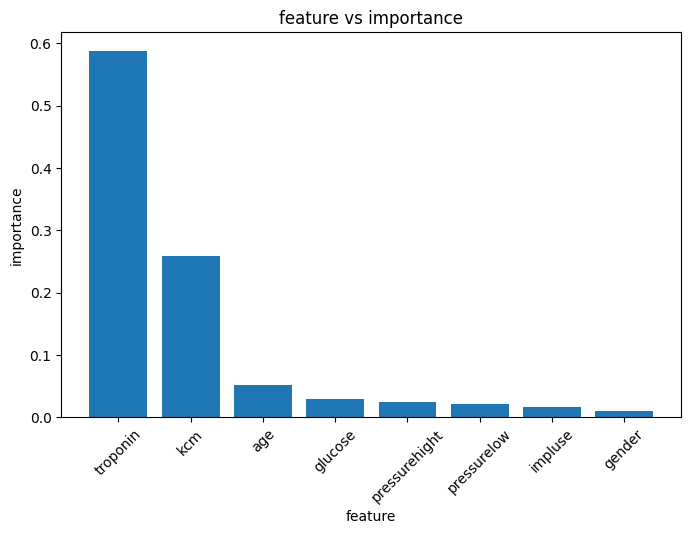

In [23]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(
    feature_importance["Feature"],
    feature_importance['importance']
)
plt.title('feature vs importance')
plt.xlabel('feature')
plt.ylabel('importance')
plt.xticks(rotation=45)

plt.show()